# Lecture 5

### Today's Topics:

- Pandas
- Data Wrangling
- Feature Types
- Loss Functions
- Linear Regression

## Pandas

![image](../attachments/pandas_logo.png)

- We will use the popular Python Data Analysis Library (Pandas).
- Open source and freely available, in collab & most distributions.
- Pandas documentation: [Getting Started](https://pandas.pydata.org/docs/getting_started/index.html)

Reading and Writing to CSV's

![image](../attachments/pandas_file_io.png)

In [ ]:
import pandas as pd
df = pd.read_csv('infile.csv')
pass
pass
pass
df.to_csv('outfile.csv', index=False)

Constructing from a dictionary:

![image](../attachments/pandas_df_from_dict.png)

### Selecting by label

![image](../attachments/babyDFwLabels.png)

In [94]:
baby = pd.read_csv("https://raw.githubusercontent.com/jsvine/babynames/refs/heads/master/data/name-counts.csv")
baby.head()

,year,name,sex,count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746


In [28]:
#  The first arguement is the row label
#       \/ 
baby.loc[1, 'name']
#            /\
#       The second arguement is the column label

'Anna'

Selects the entry in row 1, column "name" which is 'Anna'

We can also select a range of values

In [29]:
baby.loc[1:3, 'name':'count'] # is inclusive!

,name,sex,count
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939


In [26]:
# Just extract the name and count columns
baby.loc[:, ['name', 'count']]
#            list of column labels

,name,count
0,Mary,7065
1,Anna,2604
2,Emma,2003
3,Elizabeth,1939
4,Minnie,1746
...,...,...
1758725,Zylin,5
1758726,Zymari,5
1758727,Zyrin,5
1758728,Zyrus,5


What happens if you use single versus double brackets?

In [31]:
# Shorthand for baby.loc[:, 'name']
type(baby['name']), baby['name']

(pandas.Series,
 0               Mary
 1               Anna
 2               Emma
 3          Elizabeth
 4             Minnie
              ...    
 1758725        Zylin
 1758726       Zymari
 1758727        Zyrin
 1758728        Zyrus
 1758729    Zytaevius
 Name: name, Length: 1758730, dtype: str)

Returns a series (pandas equivalent to a list/vector) and not a entire dataframe

### Boolean Selection

- We can build more complex selections using Boolean selection
- Create a Series of Booleans that selects rows where the Series is True:

In [36]:
baby.loc[baby['year'] == 2000, :]
# baby.loc[baby['year'] == 2000] also works here

,year,name,sex,count
1332388,2000,Emily,F,25953
1332389,2000,Hannah,F,23069
1332390,2000,Madison,F,19967
1332391,2000,Ashley,F,17994
1332392,2000,Sarah,F,17681
...,...,...,...,...
1362146,2000,Zeph,M,5
1362147,2000,Zeven,M,5
1362148,2000,Ziggy,M,5
1362149,2000,Zo,M,5


In [41]:
baby.loc[baby['count'] == 5]

,year,name,sex,count
835,1880,Adelle,F,5
836,1880,Adina,F,5
837,1880,Adrienne,F,5
838,1880,Albertine,F,5
839,1880,Alys,F,5
...,...,...,...,...
1758725,2012,Zylin,M,5
1758726,2012,Zymari,M,5
1758727,2012,Zyrin,M,5
1758728,2012,Zyrus,M,5


## Data Wrangling

We will often want to combine or aggregate data in our analysis.

Most summary statistics are available

In [ ]:
baby['count'].mean()

np.float64(187.49936886275893)

In [ ]:
baby['count'].std()

np.float64(1590.4001929154851)

In [ ]:
baby['count'].sum()

np.int64(329760765)

### Aggregating data

How many babies are born each year?

- Can similarly group data by attributes/columns in pandas:

- `groupby()` return a Series

![image](../attachments/pandas_groupby.png)

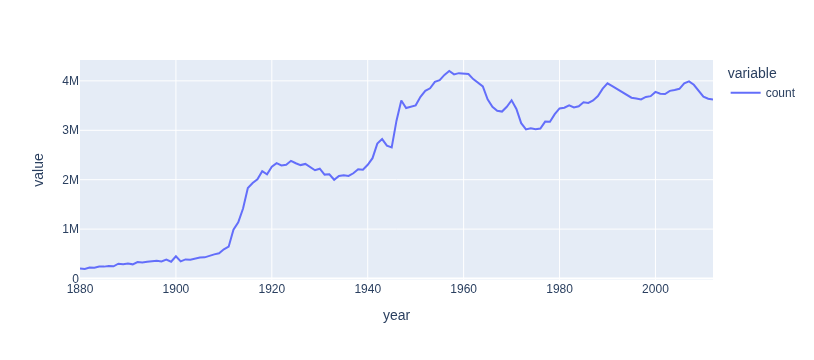

In [ ]:
count_by_year = (baby     # the dataframe
    .groupby('year')      # column to group
    ['count']             # column to aggregate
    .sum()                # how to aggregate
    )
px.line(count_by_year)

In [ ]:
unique_combos = (baby             # the dataframe
    .groupby(['sex', 'year'])     # make a group for each unique 'sex'+'year' 
    ['count']                     # aggregate the 'count' column
    .sum()                        # via summing the 'count' column
    .reset_index()                # use this sum as the new count
)

unique_combos

,sex,year,count
0,F,1880,90993
1,F,1881,91955
2,F,1882,107850
3,F,1883,112322
4,F,1884,129022
...,...,...,...
261,M,2008,2035075
262,M,2009,1977632
263,M,2010,1911572
264,M,2011,1889557


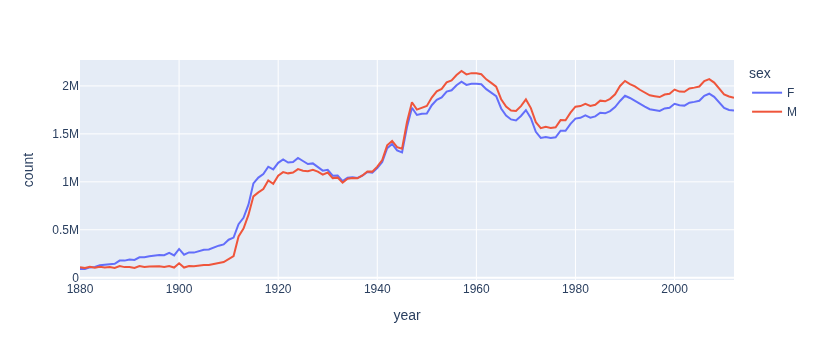

In [ ]:
px.line(unique_combos, x='year', y='count', color='sex')

### Pivoting 

- When grouping by multiple columns, a useful tool is pivoting.
- Idea: use “groupby” attributes to be row and column indices:

In [ ]:
mf_pivot = pd.pivot_table(
    baby,             # the dataframe
    index='year',     # column to make the new index
    columns='sex',    # column to turn into new columns
    values='count',   # column to aggregate for values
    aggfunc=sum)      # how to aggregate said column

mf_pivot

sex,F,M
year,,
1880,90993,110491
1881,91955,100746
1882,107850,113687
1883,112322,104630
1884,129022,114445
...,...,...
2008,1886109,2035075
2009,1831382,1977632
2010,1770632,1911572


### Zips and List Comprehension

zips: combines iterables into a single iterable.

In [ ]:
first_name = ['Alice', 'Bob', 'Charlie']
last_name = ['Hill', 'Irvin', 'Jones']
birth_year = [2003, 2006, 2004]

my_zip = zip(first_name, last_name, birth_year)
print(f'{list(my_zip)}')

[('Alice', 'Hill', 2003), ('Bob', 'Irvin', 2006), ('Charlie', 'Jones', 2004)]


In [ ]:
for first, last, year in zip(first_name, last_name, birth_year):
    print(f"{last}, {first} was born in {year}")

Hill, Alice was born in 2003
Irvin, Bob was born in 2006
Jones, Charlie was born in 2004


This is most commonly used in setting up dataframes in pandas

In [ ]:
df = pd.DataFrame(list(zip(first_name, last_name, birth_year)),
                  columns = ['First Name', 'Last Name', 'Year of Birth'])

df

,First Name,Last Name,Year of Birth
0,Alice,Hill,2003
1,Bob,Irvin,2006
2,Charlie,Jones,2004


List comprehension is an effective way to traverse lists

In [ ]:
nums = [0,1,2,3,4]
sq = [x*x for x in nums]
print(sq)

[0, 1, 4, 9, 16]


In [ ]:
evens = [num for num in range(10) if num%2 == 0]
evens

[0, 2, 4, 6, 8]

In [ ]:
even_sq = [num*num for num in range(10) if num%2 == 0]
even_sq

[0, 4, 16, 36, 64]

If you get to the point where you need a nested loop, probably best to fall back to multiple lines

In [ ]:
list1 = [1, 2, 3 ]
list2 = [1, 2, 3 ]
result = [i*k for i in list1 for k in list2]

result

[1, 2, 3, 2, 4, 6, 3, 6, 9]

## Feature Types

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/taxis.csv")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


The structure of a dataset is the arrangement in rows and columns or our mental representation of the data.

What does a row of the table represent? The answer to this question is what we refer to as the granularity of the table.

- Nominal feature: represents “named” categories that do not have a natural ordering. Examples:
    - Dog breed groups: (herding, hound, non-sporting, sporting, terrier, toy)
    - Operating systems: (Windows, MacOS, Linux)
- Ordinal feature: represents ordered categories. Examples:
    - T-shirt size (small, medium, large)
    - Likert-scale response (disagree, neutral, agree)
    - Level of education (high school, college, graduate school)

These are subtypes of **categorical data** or **qualitative data**.

**Quantitative feature**: represents numeric amounts or quantities, both continuous and discrete. 

Examples:
- Height measured to the nearest cm,
- Price reported in US Dollars
- Number of siblings

Currently the focus of our class will be on quantitative features and doing analysis on those features, we will explore ways to apply analytic methods to qualitative data later in the course

### Modeling and Estimation

Essentially, all models are wrong, but some are useful. - George Box, Statistician (1919-2013)

- A model is an idealized representation of a system.
- Example: weather forecasts make predictions that are often (in)correct
but sometimes not.

In [42]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

Code for histogram:

<Axes: xlabel='tip', ylabel='Count'>

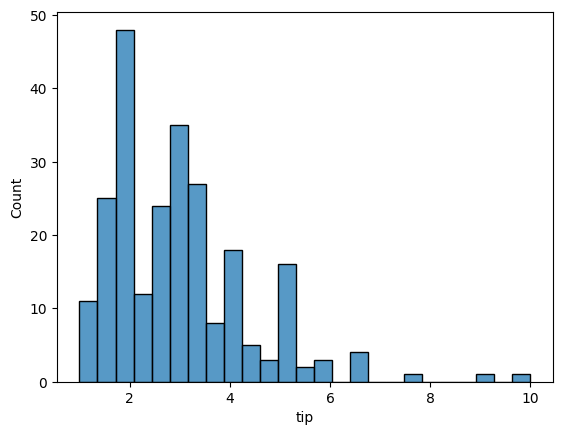

In [49]:
# for class
import seaborn as sns
sns.histplot(tips['tip'], bins=25)

We can also use a custom bin size to group values together

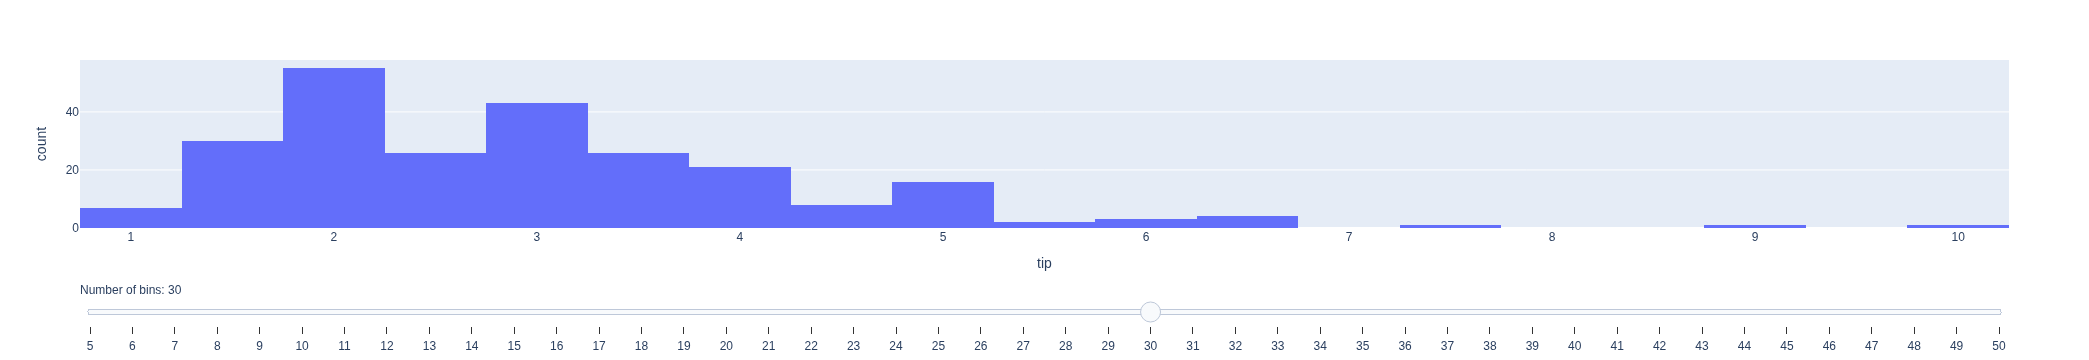

In [72]:
# more advanced visualization
# variable binning

import plotly.express as px

fig = px.histogram(tips, x="tip")
fig.update_layout(
    sliders=[{
        "active": 25,
        "currentvalue": {"prefix": "Number of bins: "},
        "pad": {"t": 50},
        "steps": [
            {
                "label": str(b),
                "method": "restyle",
                "args": [{"nbinsx": b}]
            }
            for b in range(5, 51)
        ]
    }]
)
fig.show()


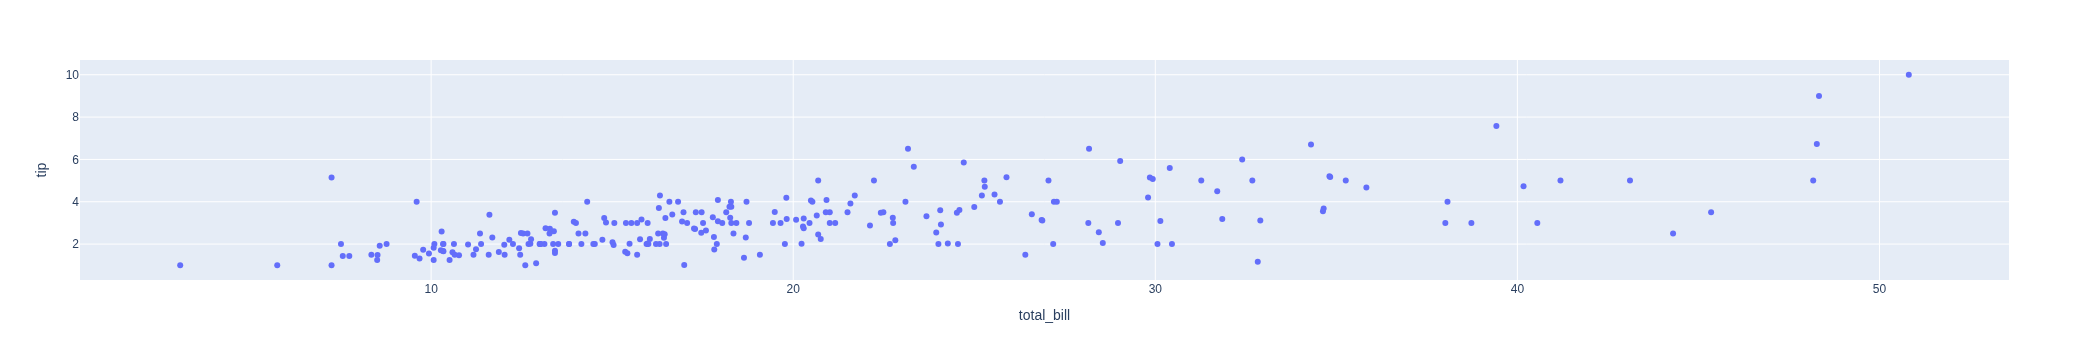

In [64]:
px.scatter(tips, x='total_bill', y='tip')

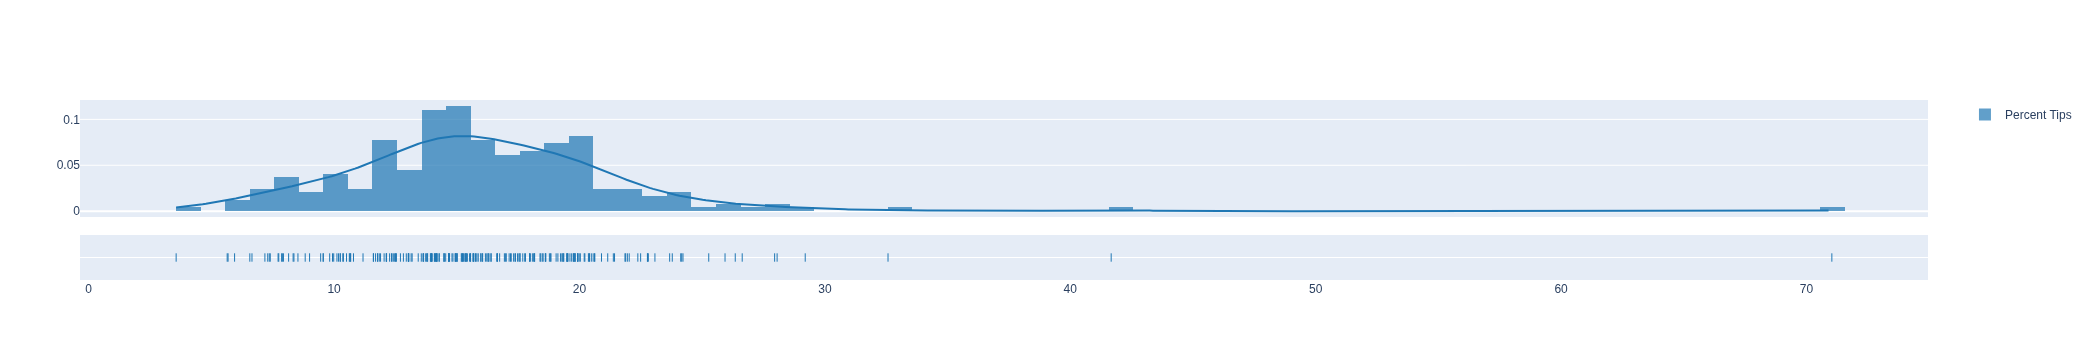

In [79]:
import plotly.figure_factory as ff

tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.show()

What would be a good estimate, $\theta$, for percent tip?

Plotly related reading: 

- [Histograms](https://plotly.com/python/histograms/)
- [Distribution Plot](https://plotly.com/python/distplot/)

## Loss Functions

- To quantify how good an estimate is, we will use loss functions.
- A loss function:
    - takes in an estimate $\theta$ and the points in our dataset, $y_1, y_2, ..., y_n$, and
    - outputs a single number, the loss, that measures how well $\theta$ fits the data
- The choice of loss function affects the downstream analysis.

Let's try something simple: taking the minimum difference, that is

$$ f(\theta, y_1, y_2, \cdots, y_n) = \min(y_1 - \theta, y_2 - \theta, \cdots, y_n - \theta)$$

Suppose $\theta = 15$, then:

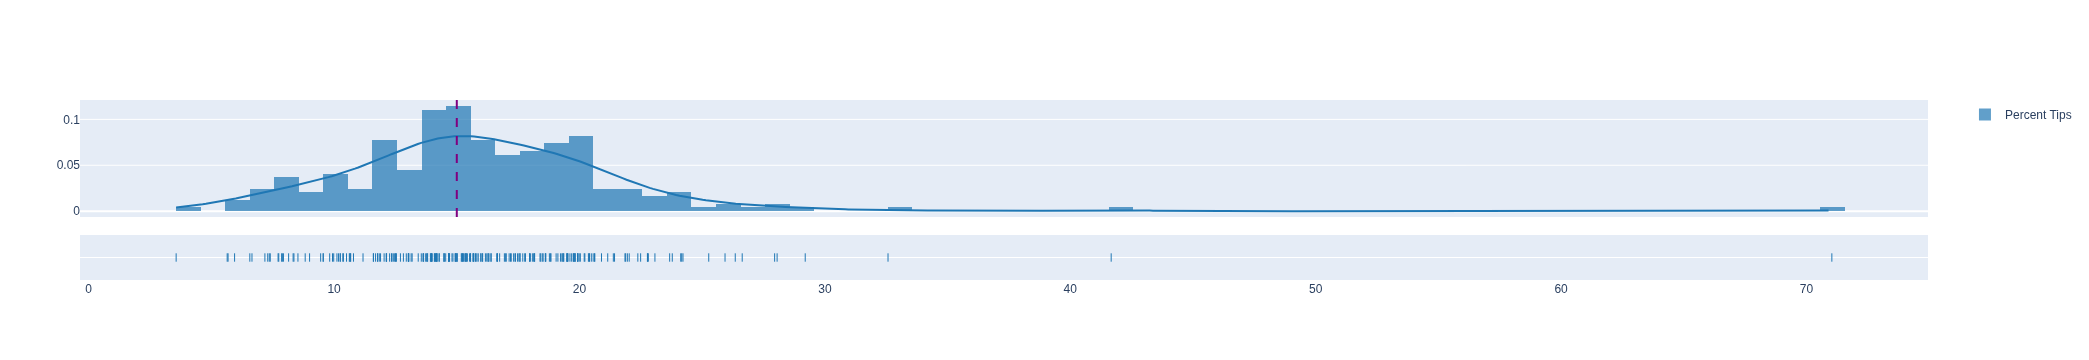

In [84]:
tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.add_vline(x=15, line_color = 'purple', line_dash = 'dash')
fig.show()

For tips, this would be for $\theta = 15$:

$$ = \min(−9.055327, 1.054159, 1.658734, \cdots , 0.974441)$$

$$ = −11.436186414864453$$

Doesn't capture much information about the values... just the smallest one

Let’s sum up the differences instead:

$$ f(\theta, y_1, y_2, \cdots, y_n) = (y_1 - \theta) + (y_2 - \theta) + \cdots + (y_n - \theta)$$

For tips, this would be $\theta = 15$:

$$ = −9.055327 + 1.054159 + 1.658734 + \cdots + 0.974441$$
$$ = 263.58299402911507$$

With the negative values, the differences are cancelling out.

To avoid the differences cancelling, make the differences positive:
- Use absolute value of the differences:
$$ f(\theta, y_1, y_2, \cdots, y_n) = |y_1 - \theta| + |y_2 - \theta| + \cdots + |y_n - \theta|$$
- Square the differences:
$$ f(\theta, y_1, y_2, \cdots, y_n) = (y_1 - \theta)^2 + (y_2 - \theta)^2 + \cdots + (y_n - \theta)^2$$

Now we're getting somewhere! We should normalize the number so we can compare it between different sample sizes.

- Mean Absolute Error: Use average of absolute value of the differences:

$$ f(\theta, y_1, y_2, \cdots, y_n) = \frac{1}{n}(|y_1 - \theta| + |y_2 - \theta| + \cdots + |y_n - \theta|)$$

- Mean Squared Error: Use average of the square the differences:

$$ f(\theta, y_1, y_2, \cdots, y_n) = \frac{1}{n}((y_1 - \theta)^2 + (y_2 - \theta)^2 + \cdots + (y_n - \theta)^2)$$

Later we will learn loss functions for more complex models

### Applying functions to Series

- Pandas has a mechanism for applying a function to every element in a
Series, called `apply`

- Similar to aggregate functions, but slower and works on a single
column of data.

In [85]:
names = baby['name']
names.apply(len)

0          4
1          4
2          4
3          9
4          6
          ..
1758725    5
1758726    6
1758727    5
1758728    5
1758729    9
Name: name, Length: 1758730, dtype: int64

We can use built in functions... or we can write our own:

In [86]:
first_letter = lambda x : x[0]

names.apply(first_letter)

0          M
1          A
2          E
3          E
4          M
          ..
1758725    Z
1758726    Z
1758727    Z
1758728    Z
1758729    Z
Name: name, Length: 1758730, dtype: str

Since apply returns a series, we can use it to create a new column in our dataframe.

In [96]:
baby['firsts'] = names.apply(first_letter)
baby.head()

,year,name,sex,count,firsts
0,1880,Mary,F,7065,M
1,1880,Anna,F,2604,A
2,1880,Emma,F,2003,E
3,1880,Elizabeth,F,1939,E
4,1880,Minnie,F,1746,M


alternatively:

In [98]:
baby = baby.assign(firsts=names.apply(first_letter))
baby.head()

,year,name,sex,count,firsts
0,1880,Mary,F,7065,M
1,1880,Anna,F,2604,A
2,1880,Emma,F,2003,E
3,1880,Elizabeth,F,1939,E
4,1880,Minnie,F,1746,M


Last thing, let's step by step take the MSE for our `tips` dataframe

This will be our pipeline:

1. Calculate the `difference` between each item and 15
2. Calculate the `squared` value of each of the values in `difference`
3. Sum the `squared` row
4. Divide by the number of rows we have

In [101]:
n = 15
difference_fn = lambda x : x-15

tips = tips.assign(difference=tips['percent'].apply(difference_fn))
tips.head()

,total_bill,tip,sex,smoker,day,time,size,percent,difference
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,-9.055327
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,1.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,1.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,-1.021959
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,-0.319235


In [103]:
squared_fn = lambda x : x**2

tips = tips.assign(squared=tips['difference'].apply(squared_fn))
tips.head()

,total_bill,tip,sex,smoker,day,time,size,percent,difference,squared
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,-9.055327,81.998941
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,1.054159,1.111250
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,1.658734,2.751398
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,-1.021959,1.044401
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,-0.319235,0.101911


In [110]:
tips['squared'].sum() / tips['squared'].count()

np.float64(38.31223773226083)

Let's combine this into one function:

In [125]:
def calculate_loss(df, theta, func = lambda x : x**2):
    difference_fn = lambda x : x-theta
    
    df = df.assign(difference=df['percent'].apply(difference_fn))
    df = df.assign(new=df['difference'].apply(func))
    return df['new'].sum() / df['new'].count()

In [140]:
calculate_loss(tips, 10)

np.float64(74.11481945476554)

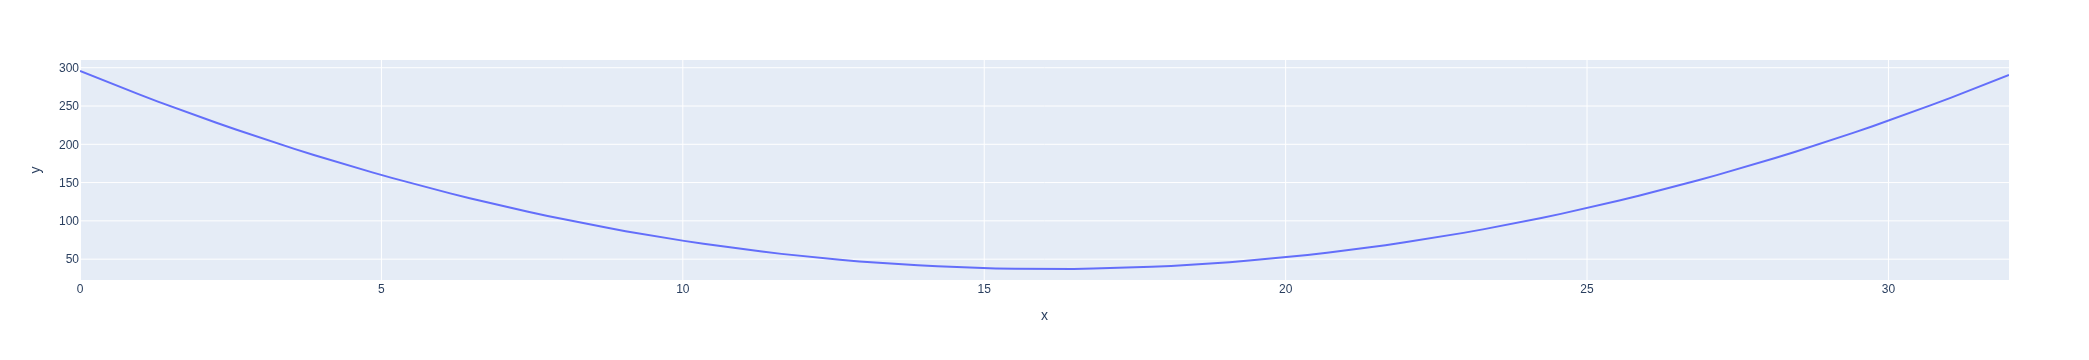

In [137]:
import numpy as np

thetas = np.linspace(0, 32, 100)
losses = [calculate_loss(tips, theta) for theta in thetas]

px.line(x=thetas,y=losses)

In [142]:
min_idx = np.argmin(losses)
print(f'Minimum Theta: {thetas[min_idx]}')
print(f'Minimum MSE: {losses[min_idx]}')

Minimum Theta: 16.161616161616163
Minimum MSE: 37.15189913598053


### Linear Models

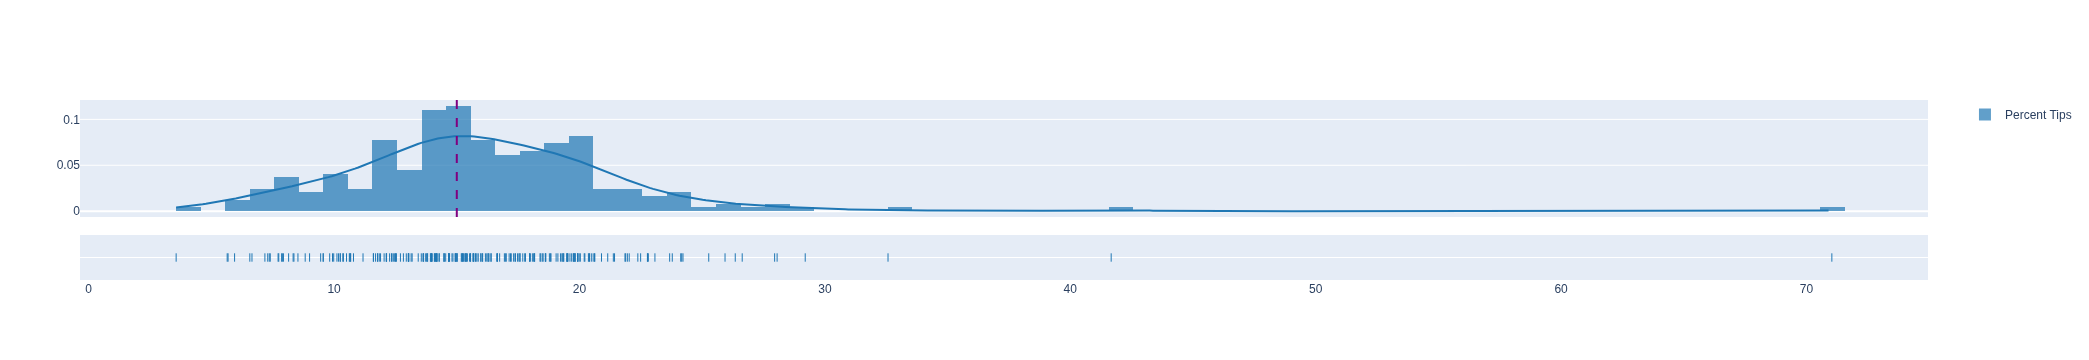

In [ ]:
import plotly.figure_factory as ff

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.add_vline(x=15, line_color = 'purple', line_dash = 'dash')
fig.show()

- Introduced a new variable: Percent Tip Amount.
- Asked what’s a good estimate, $\theta$, for percent tip?
- Seeking a single number, or constant model, for percent tip.

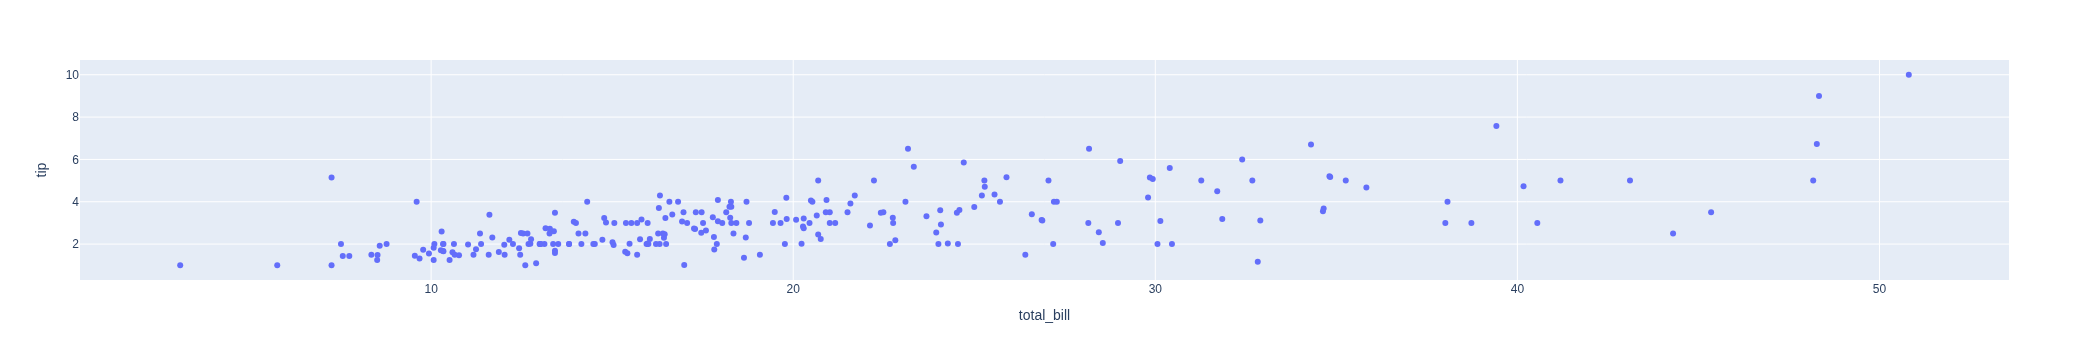

In [ ]:
px.scatter(tips, x='total_bill', y='tip')

- Construct models to understand data and make predictions.
- First: focus on models which seek to explain outputs (dependent variable) via a linear function of the inputs (independent variable).
- Example: If the bill is \$20, what will the tip be?
    - Are there values for $m$ and $b$ so we can use a equation $y = mx + b$?
- $bill$ is the independent variable, and $tip$ is the dependent variable.

$$ \text{tip} = m*\text{bill} + b$$

Our model:

- m = 15\%
- b = 0

$$ \text{tip} = 0.15* \text{bill} + 0$$

But there are infinitely many linear models that we can use, how do we determine which one is best?

That's what our loss function solves.